# 06. 비정상 밴디트와 고정 학습률

지금까지는 각 슬롯머신의 보상 분포가 일정한 환경을 다뤘다. 이번에는 **시간에 따라 당첨 확률이 변하는 환경**에서 행동 가치를 어떻게 추정할지 살펴본다.


In [8]:
import numpy as np
import matplotlib.pyplot as plt
from bandit import Bandit, Agent
plt.rcParams['font.family'] = 'AppleGothic'   # macOS

plt.rcParams['axes.unicode_minus'] = False

rng = np.random.default_rng(22)

## 1. 변화하는 환경 구현

정상 환경 `Bandit`은 머신별 당첨 확률을 처음에 정한 뒤 유지한다. 비정상 환경 `NonStat`은 한 번 플레이할 때마다 **모든 머신의 확률**에 평균 0인 정규 잡음을 더한다.

아래 구현은 현재 확률로 보상을 생성한 다음, 다음 플레이에 사용할 확률을 갱신한다. 선택하지 않은 머신의 확률도 변하므로 과거에 좋았던 머신이 계속 좋다는 보장은 없다.

확률은 0과 1 사이여야 하므로 `np.clip()`으로 범위를 제한한다. 이는 경계에서 값을 잘라내는 모델링 선택이며, 경계 근처의 변화는 제한 없는 정규 잡음과 달라진다. 실험에 사용하는 `NonStatBandit`도 같은 규칙을 적용한다.

In [9]:
class NonStat:
    def __init__(self, arms=10, seed=22):
        self.arms = arms
        self.rng = np.random.default_rng(seed)
        self.rates = self.rng.random(arms)

    def play(self, arm):
        # 현재 확률로 보상을 생성한다.
        reward = int(self.rng.random() < self.rates[arm])
        # 다음 시행에 사용할 모든 머신의 확률을 갱신한다.
        noise = 0.1 * self.rng.standard_normal(self.arms)
        self.rates = np.clip(self.rates + noise, 0.0, 1.0)
        return reward


## 2. 정규 잡음 확인하기

`rng.standard_normal(N)`은 평균 0, 표준편차 1인 표준정규분포에서 난수를 뽑는다. 양수와 음수가 모두 나오므로 당첨 확률이 올라가거나 내려가는 변화를 표현할 수 있다.

히스토그램은 0 근처의 값이 자주 나오고 큰 절댓값은 상대적으로 드문 모습을 보여준다. 환경에서는 이 난수에 0.1을 곱해 변화의 크기를 조절한다. 이것은 ‘매번 확률이 정확히 0.1만큼 변한다’는 뜻이 아니다.

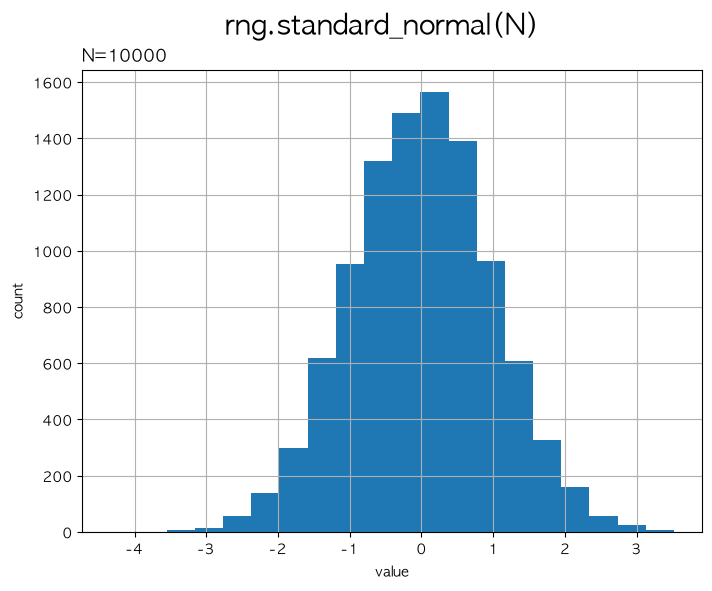

In [10]:
N = 10000

# 화이트 노이즈 생성
r_vals = rng.standard_normal(N)

# 난수 히스토그램 만들기 
plt.figure(figsize=( 8 , 6 ))
plt.hist(r_vals, bins= 20 ) 
plt.xlabel( 'value' )
plt.ylabel( 'count' )
plt.title( 'N=' + str (N), loc= 'left' ) # 데이터 수 
plt.suptitle( 'rng.standard_normal(N)' , fontsize= 20 )
plt.grid()
plt.show()

## 3. 표본평균에서 고정 학습률로

같은 머신에서 얻은 보상을 차례로 관측한다고 하자. $n$은 **해당 머신의 관측 횟수**이다. 표본평균 갱신은 다음과 같다.

$$Q_n=Q_{n-1}+\frac{1}{n}(R_n-Q_{n-1}).$$

관측이 쌓일수록 학습률이 작아진다. 정상 환경에서는 변동을 줄이는 데 도움이 되지만, 환경이 바뀌면 새로운 보상의 영향이 작아 적응이 느려질 수 있다.

이를 보완하기 위해 학습률을 일정하게 유지한다.

$$Q_n=Q_{n-1}+\alpha(R_n-Q_{n-1}),\qquad 0<\alpha\le1.$$

이전 추정치에서 새 보상 쪽으로 차이의 일정 비율만큼 이동한다. 아래에서는 $0<\alpha<1$인 경우를 살펴본다. $\alpha=1$이면 가장 최근 보상만 추정치로 사용한다.

### 과거 보상에 부여되는 가중치

갱신식을 반복해서 대입하면 다음과 같다.

$$Q_n=\alpha R_n+\alpha(1-\alpha)R_{n-1}+\cdots+\alpha(1-\alpha)^{n-1}R_1+(1-\alpha)^nQ_0.$$

최신 보상의 가중치는 $\alpha$이고, 한 관측씩 오래될 때마다 $1-\alpha$를 곱한다. 따라서 오래된 보상의 영향이 지수적으로 줄어든다.

- 표본평균: 지금까지의 보상을 같은 가중치로 반영한다.
- 고정 학습률: 최근 보상을 더 크게 반영한다.

아래 막대그래프는 보상에 대한 가중치만 표시한다. 고정 학습률에서는 보상 가중치의 합이 $1-(1-\alpha)^n$이고, 나머지는 초기 추정치 $Q_0$의 가중치이다. **초기값의 가중치까지 포함하면 합이 1**이다. $Q_0=0$이어도 초기값 항의 가중치 자체가 사라지는 것은 아니다.

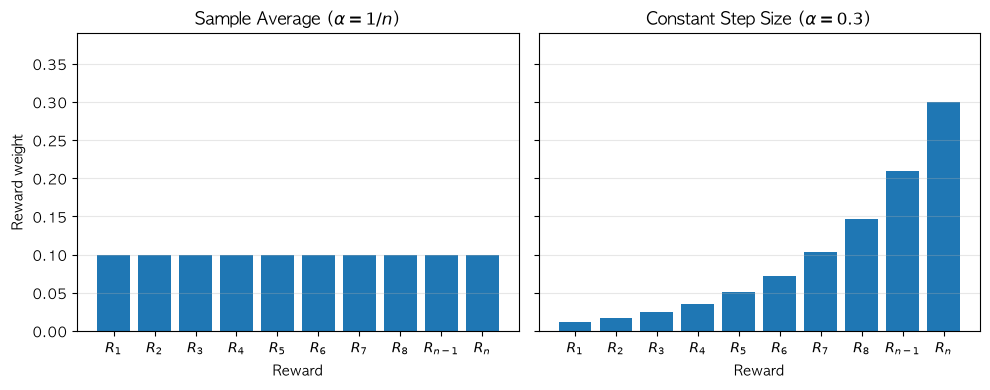

In [11]:

# 더미 설정
n = 10
alpha = 0.3
sample_weights = np.ones(n) / n
constant_weights = np.array([
    alpha * (1 - alpha) ** (n - i)
    for i in range(1, n + 1)
])

labels = [f"$R_{i}$" for i in range(1, n + 1)]
labels[-2] = r"$R_{n-1}$"

labels[-1] = r"$R_n$"

fig, axes = plt.subplots(1, 2, figsize=(10, 4), sharey=True)

#  표본평균 (1)
axes[0].bar(labels, sample_weights)
axes[0].set_xlabel("Reward")
axes[0].set_ylabel("Reward weight")
axes[0].set_title(r"Sample Average ($\alpha = 1/n$)")

# 고정 학습률 (2)
axes[1].bar(labels, constant_weights)
axes[1].set_xlabel("Reward")
axes[1].set_title(r"Constant Step Size ($\alpha = 0.3$)")


# 동일한 y축 범위로 비교
ymax = max(max(sample_weights), max(constant_weights)) * 1.3
axes[0].set_ylim(0, ymax)

for ax in axes:
    ax.grid(axis="y", alpha=0.3)




plt.tight_layout()
plt.show()

## 4. 학습률에 따른 가중치 감소

이 그래프의 $k$는 전체 플레이 횟수가 아니라 **최신 보상으로부터 몇 관측 이전인가**를 나타낸다. $k=0$은 최신 보상, $k=1$은 바로 이전 보상이다.

$$w_k=\alpha(1-\alpha)^k.$$

- 큰 학습률: 최신 보상에 큰 가중치를 주고 과거의 영향을 빠르게 줄인다. 변화에는 빠르게 반응하지만 우연한 보상에도 크게 흔들릴 수 있다.
- 작은 학습률: 더 오래된 정보를 유지하여 부드럽게 변하지만, 환경 변화에 늦게 반응할 수 있다.

머신을 선택하지 않는 동안에는 추정치도 갱신되지 않는다. 여기서 가중치 감소는 벽시계 시간이나 전체 시행 횟수가 아닌 **그 머신의 새 관측이 들어오는 횟수**를 기준으로 한다.

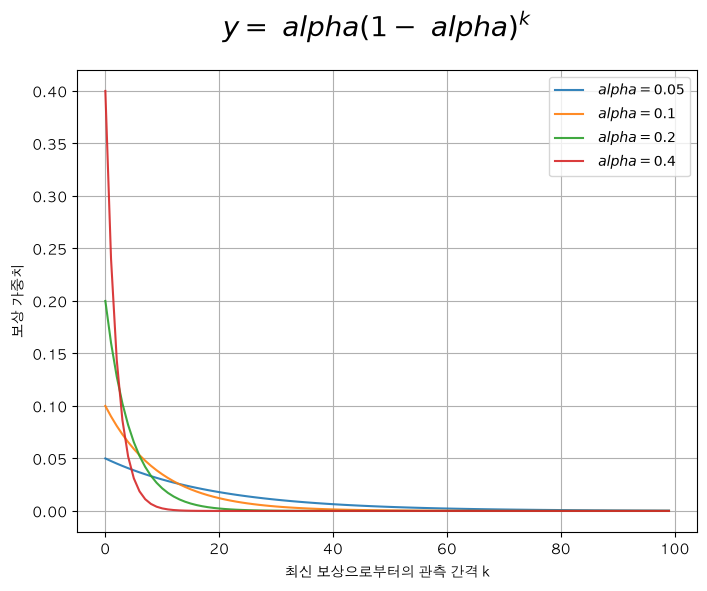

In [12]:
# 고정 학습률 지정 
alpha_list = [ 0.05 , 0.1 , 0.2 , 0.4 ]

# 시도 횟수 지정 
n = 100

# x축 값 만들기
k = np.arange(n)

# 지수 이동 평균 가중치 차트 만들기 
plt.figure(figsize=( 8 , 6 ))
for alpha in alpha_list:
    plt.plot(k, alpha * ( 1 - alpha)**k, alpha= 0.9 , label= '$ \\ alpha=' + str (alpha)+ '$' ) # 시도 횟수와 가중치의 관계 
plt.xlabel('최신 보상으로부터의 관측 간격 k')
plt.ylabel('보상 가중치')
plt.suptitle( '$y = \\ alpha (1 - \\ alpha)^k$' , fontsize= 20 )
plt.grid()
plt.legend()
plt.show()

## 5. 같은 비정상 환경에서 갱신 방법 비교

두 에이전트 모두 **비정상 환경에서 ε-greedy로 행동을 선택**한다. 차이는 행동 가치 추정치를 갱신하는 방법이다.

| 에이전트 | 갱신 방법 |
|---|---|
| `Agent` | 머신별 관측 횟수에 따른 표본평균 |
| `AlphaAgent` | 고정 학습률을 이용한 갱신 |

`epsilon`은 탐험할 확률이고, `alpha`는 새 보상을 추정치에 반영하는 비율이다. 서로 다른 역할을 한다.

각 방법에 대해 1,000번 플레이하는 실험을 200번 반복한다. 매 실험마다 환경과 에이전트를 초기화한다. 같은 실험 번호에는 같은 환경 시드를 사용하여 두 방법이 같은 확률 변화 과정을 경험하도록 한다. 에이전트의 난수는 환경 난수와 분리한다.

`rates`는 한 실험에서 지금까지의 전체 평균 보상이며, `results`에는 이를 여러 실험에 걸쳐 평균한 곡선을 저장한다. 이 값은 특정 머신의 행동 가치 추정치와 다르다.

현재 `alpha=0.8`은 새 보상을 크게 반영하는 설정이다. 고정 학습률이면 항상 좋은 것이 아니라, 환경 변화 속도와 보상 잡음에 맞는 값을 선택해야 한다.

In [13]:
from non_stationary import NonStatBandit, AlphaAgent

# 실험 수
runs = 200

# 시도 횟수 지정 
N = 1000

# 슬롯머신 수 지정 
K = 10

# 무작위로 슬롯머신를 선택할 확률을 지정 
epsilon = 0.1

# 고정 학습률 지정 
alpha = 0.8

# 에이전트 전환을 위한 설정 
agent_types = [ 'sample average' , 'alpha const update' ]

# 실험 결과의 평균 기록을위한 사전을 초기화
results={}

# 에이전트 클래스 전환 
for agent_type in agent_types:
    print (agent_type)
    
    # 실험 결과 기록을 위한 배열 초기화
    all_rates = np.zeros((runs, N))
    
    # 반복 시도 
    for run in  range ( runs):
         # 인스턴스 생성
        bandit = NonStatBandit(K, seed=22 + run)
        np.random.seed(10000 + run)  # 에이전트용 난수; 환경과 분리
        if agent_type == 'sample average' :
             # 표본평균 갱신 
            agent = Agent(epsilon, K)
        else :
             # 고정 학습률 갱신 
            agent = AlphaAgent(epsilon, alpha, K)
        
        # 평균 보상 기록을 위한 객체 초기화 
        total_reward = 0
        rates=[]
        
        # 반복 시도 
        for step in  range (N):
             # 버전 플레이
            action = agent.get_action()
            reward = bandit.play(action)

            # 슬롯머신를의 추정 가치 업데이트
            agent.update(action, reward)

            # 평균 보상 기록
            total_reward +=reward
            rates.append (total_reward / (step + 1 ))
        
        # 실험 결과 기록
        all_rates[run] = rates

    # 각 시도에 대한 평균 계산 
    avg_rates = np.average(all_rates, axis= 0 )
    
    # 에이전트 당 실험 결과의 평균 기록
    results[agent_type] = avg_rates
    print (avg_rates[- 1 ])

sample average
0.6067800000000001
alpha const update
0.7164999999999994


## 6. 결과 해석

각 선은 한 갱신 방법의 실험들을 평균한 결과이다. 초반과 후반에 어느 방법이 더 높은 평균 보상을 보이는지 비교한다.

표본평균은 과거 정보를 오래 유지하고, 고정 학습률은 최근 정보에 더 민감하다. 비정상 환경에서는 최근 정보가 유용할 수 있지만, 고정 학습률이 모든 실행과 모든 설정에서 반드시 우수한 것은 아니다.

그래프는 **지금까지의 누적 보상을 플레이 횟수로 나눈 평균**이다. 현재 순간의 성능이나 특정 머신의 변화 추적 오차를 직접 보여주지는 않는다. 여러 실험의 변동 범위도 표시하지 않으므로 작은 차이를 과도하게 해석하지 않는다.

## 확인 질문과 추가 실습

1. 보상이 매번 달라진다고 모두 비정상 환경인가?
2. 표본평균은 관측이 많아진 뒤 환경이 바뀌면 왜 적응이 느릴까?
3. 학습률을 크게 하면 어떤 이점과 단점이 생기는가?
4. 탐험이 부족하면 고정 학습률만으로 다른 머신의 변화를 알아낼 수 있을까?

`alpha`를 0.05, 0.1, 0.3, 0.8로 바꾸고 같은 실험 조건에서 비교해 보자. 환경의 잡음 크기도 바꾸면 변화 속도에 따라 유리한 학습률이 달라지는지 살펴볼 수 있다.

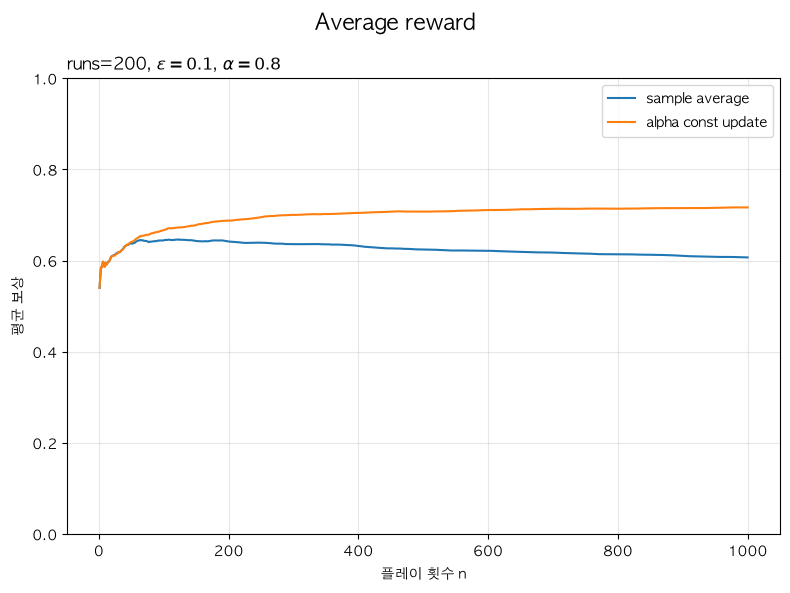

In [14]:
# 실험 결과를 그리기
fig, ax = plt.subplots(figsize=(8, 6))

for key, avg_rates in results.items():
    x = np.arange(1, len(avg_rates) + 1)
    ax.plot(x, avg_rates, label=key)

ax.set_xlabel("플레이 횟수 n")
ax.set_ylabel("평균 보상")
ax.set_title(
    rf"runs={runs}, $\epsilon={epsilon}$, $\alpha={alpha}$",
    loc="left"
)
fig.suptitle("Average reward", fontsize=16)

ax.grid(alpha=0.3)
ax.legend()
ax.set_ylim(0, 1)

plt.tight_layout()
plt.show()